In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
historical_data = pd.read_csv('historical_data.csv')
fear_greed = pd.read_csv('fear_greed_index.csv')

In [3]:
print("Historical Data Shape:", historical_data.shape)
print("Fear & Greed Shape:", fear_greed.shape)

historical_data.head()

Historical Data Shape: (65149, 16)
Fear & Greed Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
# Historical dataset information
historical_data.info()

print("\n" + "="*60 + "\n")

# Fear & Greed dataset information
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
# Check missing values

print("Historical Data Missing Values:")
print(historical_data.isnull().sum())

print("\n" + "="*60 + "\n")

print("Fear & Greed Missing Values:")
print(fear_greed.isnull().sum())

Historical Data Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Fear & Greed Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
print("Historical Data Columns:\n")
print(historical_data.columns.tolist())

print("\n" + "="*70 + "\n")

print("Fear & Greed Columns:\n")
print(fear_greed.columns.tolist())

Historical Data Columns:

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


Fear & Greed Columns:

['timestamp', 'value', 'classification', 'date']


In [9]:
print("Historical Timestamp IST:")
print(historical_data['Timestamp IST'].head())

print("\nFear & Greed Date:")
print(fear_greed['date'].head())

Historical Timestamp IST:
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

Fear & Greed Date:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [10]:
# Convert Timestamp IST to datetime
historical_data['Timestamp IST'] = pd.to_datetime(
    historical_data['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create a date-only column
historical_data['date'] = historical_data['Timestamp IST'].dt.date

# Convert Fear & Greed date
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

print(historical_data[['Timestamp IST', 'date']].head())

print("\n")

print(fear_greed[['date', 'classification']].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [11]:
# Merge Historical Data with Fear & Greed Data

merged_data = pd.merge(
    historical_data,
    fear_greed[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged Shape:", merged_data.shape)

merged_data.head()

Merged Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [12]:
merged_data['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


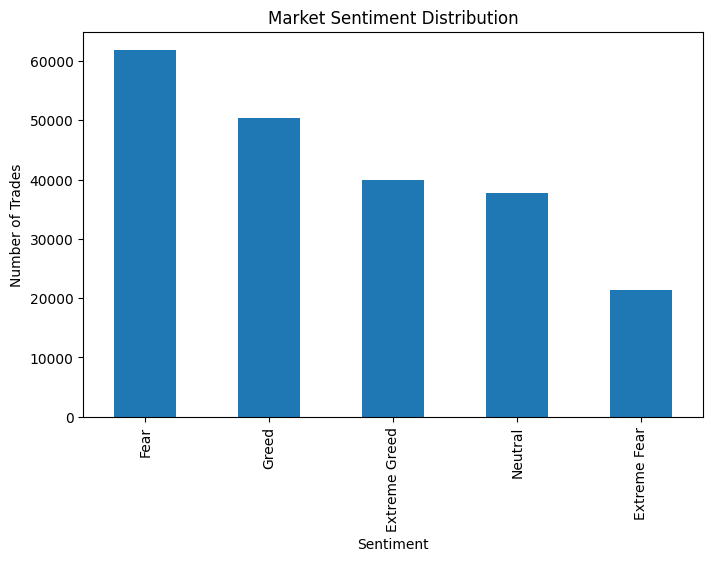

In [13]:
import matplotlib.pyplot as plt

merged_data['classification'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [14]:
merged_data['Closed PnL'].describe()

,Closed PnL
count,211224.000000
mean,48.749001
std,919.164828
min,-117990.104100
25%,0.000000
50%,0.000000
75%,5.792797
max,135329.090100


In [15]:
merged_data.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [16]:
buy_sell = merged_data.groupby('Side')['Closed PnL'].mean()
print(buy_sell)

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64


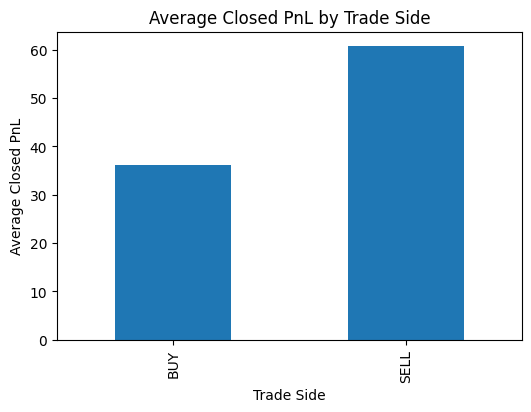

In [17]:
import matplotlib.pyplot as plt

buy_sell.plot(kind='bar', figsize=(6,4))

plt.title("Average Closed PnL by Trade Side")
plt.xlabel("Trade Side")
plt.ylabel("Average Closed PnL")
plt.show()

In [20]:
print(merged_data.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'value'],
      dtype='object')


In [22]:
merged_data.groupby("Direction")["Closed PnL"].mean()

,Closed PnL
Direction,
Auto-Deleveraging,7184.807003
Buy,0.000000
Close Long,74.426422
Close Short,103.012804
Liquidated Isolated Short,-12752.913040
Long > Short,34.936474
Open Long,0.000000
Open Short,0.000000
Sell,146.053081


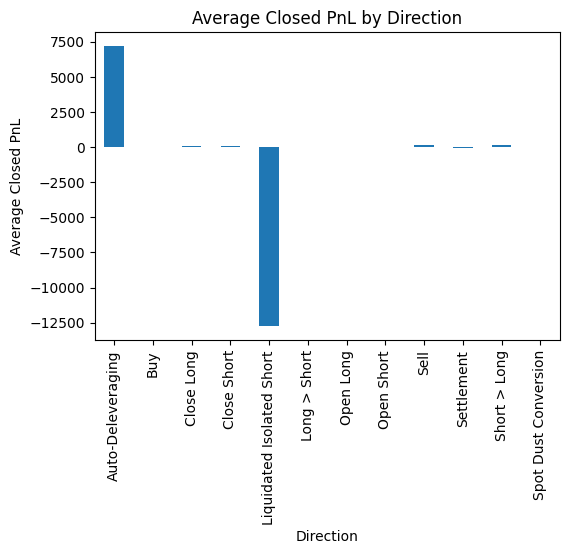

In [23]:
direction = merged_data.groupby("Direction")["Closed PnL"].mean()

direction.plot(kind="bar", figsize=(6,4))

plt.title("Average Closed PnL by Direction")
plt.xlabel("Direction")
plt.ylabel("Average Closed PnL")
plt.show()

In [24]:
coin_profit = merged_data.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False)

print(coin_profit)

Coin
@109      270.704207
AVAX      239.095613
ENA       219.524751
@85       200.804091
EIGEN     197.063189
            ...     
S         -60.033651
IO        -62.198609
@147      -70.126539
TRUMP    -190.012973
@135    -5981.363990
Name: Closed PnL, Length: 246, dtype: float64


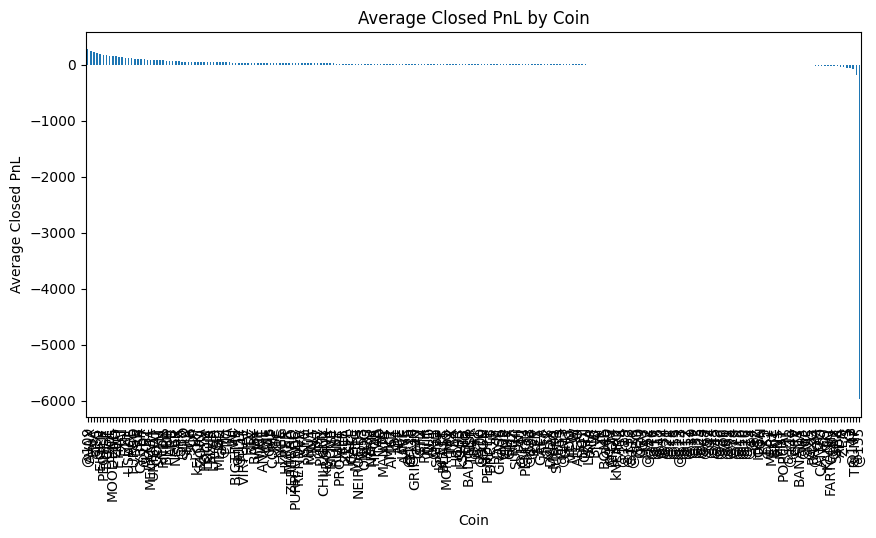

In [25]:
plt.figure(figsize=(10,5))

coin_profit.plot(kind="bar")

plt.title("Average Closed PnL by Coin")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.show()

classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: Closed PnL, dtype: float64


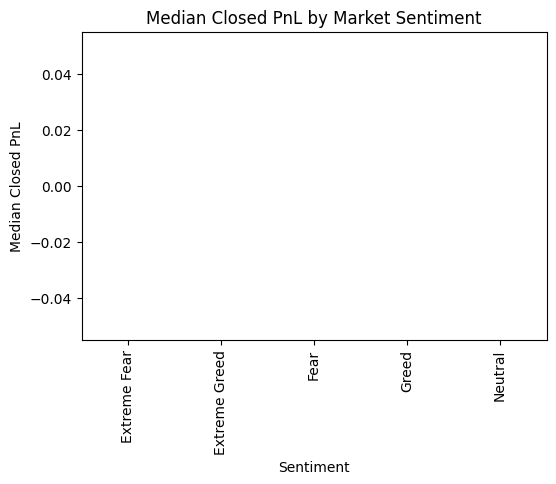

In [26]:
# Median Closed PnL by Sentiment

median_pnl = merged_data.groupby("classification")["Closed PnL"].median()

print(median_pnl)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
median_pnl.plot(kind="bar", color="green")

plt.title("Median Closed PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Median Closed PnL")

plt.show()

In [27]:
# Create a Winning Trade column
merged_data["Winning Trade"] = merged_data["Closed PnL"] > 0

# Calculate Win Rate by sentiment
win_rate = merged_data.groupby("classification")["Winning Trade"].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Winning Trade, dtype: float64


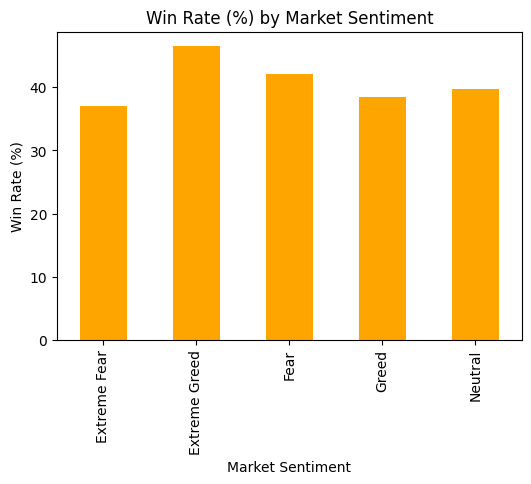

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

win_rate.plot(kind="bar", color="orange")

plt.title("Win Rate (%) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [29]:
merged_data.groupby("classification")["Fee"].mean()

,Fee
classification,
Extreme Fear,1.116291
Extreme Greed,0.675902
Fear,1.495172
Greed,1.254372
Neutral,1.044798


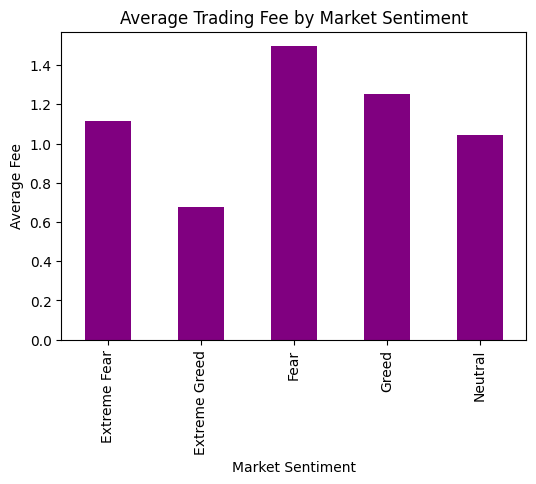

In [30]:
fee_avg = merged_data.groupby("classification")["Fee"].mean()

plt.figure(figsize=(6,4))
fee_avg.plot(kind="bar", color="purple")

plt.title("Average Trading Fee by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")

plt.show()

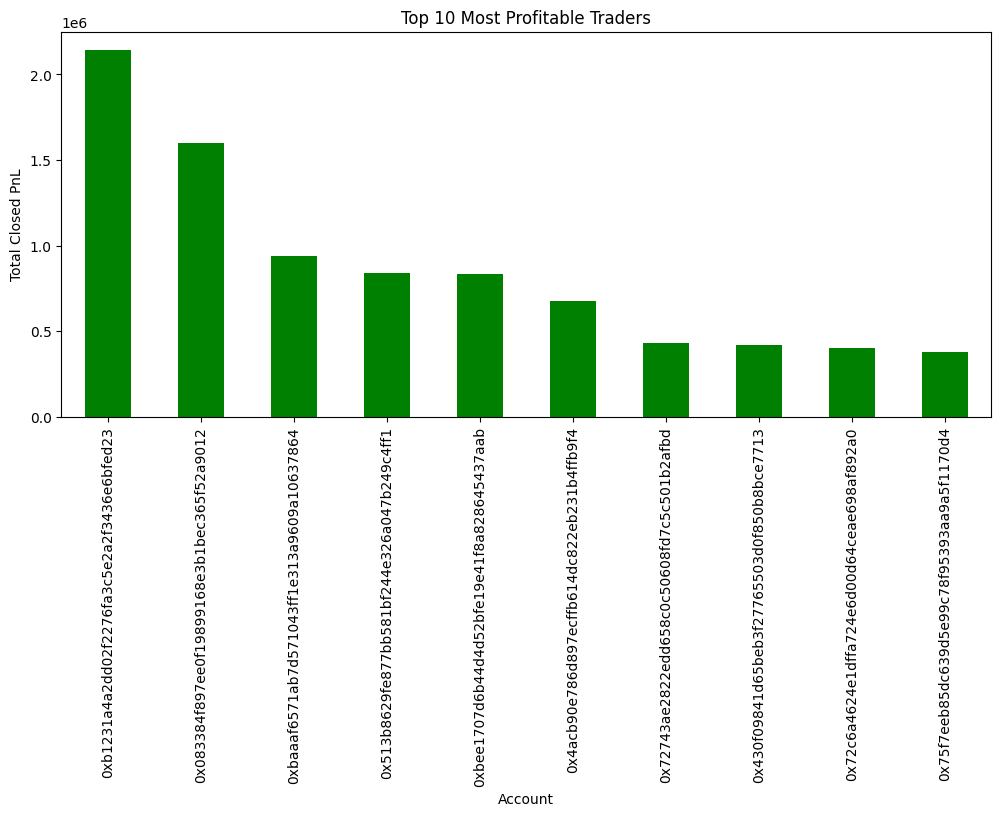

In [31]:
top10 = merged_data.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top10.plot(kind="bar", color="green")

plt.title("Top 10 Most Profitable Traders")
plt.ylabel("Total Closed PnL")

plt.show()

# Key Insights

- Fear was the most common market sentiment in the dataset.
- Extreme Greed showed the highest win rate (~46.4%).
- Extreme Fear showed the lowest win rate (~37.1%).
- Median Closed PnL remained 0 across all sentiment categories.
- Trading fees were highest during Fear and lowest during Extreme Greed.
- A small number of traders generated exceptionally high profits.

# Conclusion

This analysis explored the relationship between market sentiment and trader performance.

The results show that trader success varies across different market conditions. Extreme Greed produced the highest winning percentage, while Extreme Fear had the lowest. These findings can help build sentiment-aware trading strategies and improve decision-making in cryptocurrency markets.